In [ ]:
%pip check

In [1]:
# Get Data from Lakehouse Silver Layer to visualize and analyse features of dataset
df = spark.read.table("lh_CustomerChurn.silver.customerchurn").toPandas()
display(df.head())

StatementMeta(, 02556692-c2bb-4a41-a16b-1850127d5dc5, 7, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, b58bbfcd-7260-4ec1-8dd3-a7a0296b578b)

StatementMeta(, 02556692-c2bb-4a41-a16b-1850127d5dc5, 9, Finished, Available, Finished, False)

<Axes: xlabel='cr8b0_churnstatus', ylabel='count'>

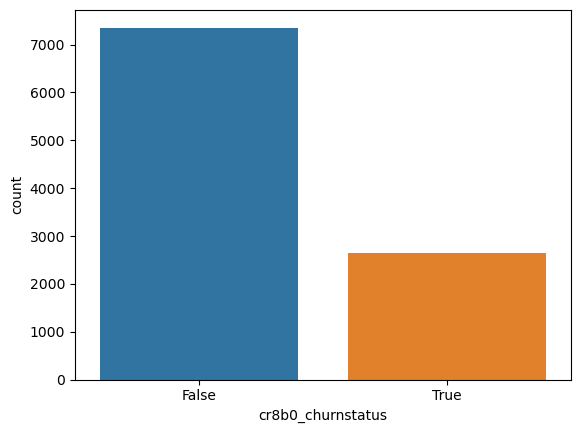

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the class balance
sns.countplot(df, x='cr8b0_churnstatus')


In [ ]:
sns.violinplot(df, x='cr8b0_churnstatus', y='cr8b0_tenuremonths')


StatementMeta(, 02556692-c2bb-4a41-a16b-1850127d5dc5, 10, Finished, Available, Finished, False)

<Axes: >

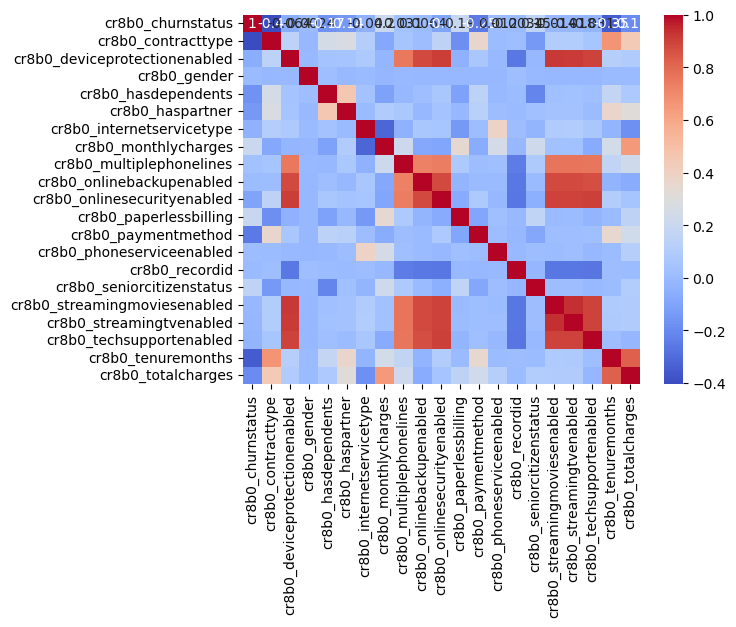

In [3]:
df = df.drop(['cr8b0_customerid','cr8b0_customersubscriptionid'], axis=1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

StatementMeta(, 02556692-c2bb-4a41-a16b-1850127d5dc5, 11, Finished, Available, Finished, False)

<Axes: xlabel='cr8b0_contracttype', ylabel='count'>

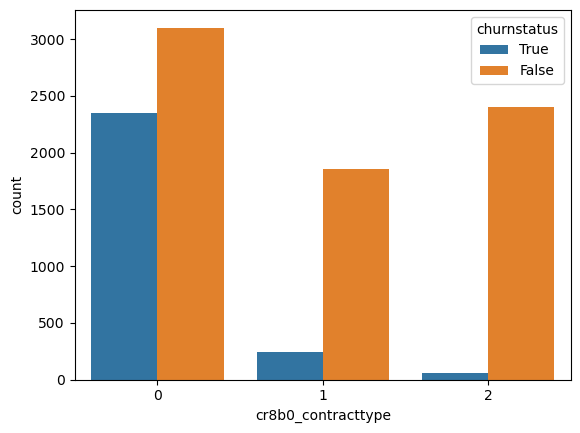

In [4]:
df["churnstatus"] = df["cr8b0_churnstatus"].astype(str)
sns.countplot(df, x='cr8b0_contracttype', hue='churnstatus')

In [1]:
import mlflow.sklearn
import pandas as pd
from decimal import Decimal
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel

# 1. Get data as Panda DataFrame from the Silver Layer Lakehouse table
df = spark.read.table("lh_CustomerChurn.silver.customerchurn").toPandas()
df = df.drop_duplicates()

# 1b. Convert decimal-columns (coming as object/decimal from Spark) into float
decimal_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, Decimal)).any()]
print(f"Decimal-columns converted: {decimal_cols}")
df[decimal_cols] = df[decimal_cols].astype(float)

# 2. Handle Null values
rows_before = len(df)
df = df.dropna()
print(f"Deleted rows (Nulls): {rows_before - len(df)} von {rows_before}")

# 3. Define X / y 
sensitive = df['cr8b0_gender']
X = df.drop(columns=['cr8b0_churnstatus', 'cr8b0_customerid', 'cr8b0_customersubscriptionid', 'cr8b0_gender'])
y = df['cr8b0_churnstatus']

# 4. Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# get gender values for fairness check in 7.
sensitive_test = sensitive.loc[X_test.index] 

# 4.1 Baseline of model training for drift checking with Evidently
baseline_df = X_train.copy()
baseline_df['cr8b0_churnstatus'] = y_train.values

# Save baseline for into new silver table 
spark.createDataFrame(baseline_df).write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("lh_CustomerChurn.silver.original_training_data")

print("Saved training data for drift check!")

# 5. Preprocessing: detect categorical columns

# Automatically find all text/category columns (dtype "object" or "category")
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_features}")

# One-hot encoding: turns each category into its own 0/1 column
# handle_unknown="ignore": categories unseen during training become all zeros
#   at test/inference time instead of raising an error
# sparse_output=False: returns a regular NumPy array instead of a sparse matrix
#   (easier to work with, but uses more memory)
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# ColumnTransformer applies different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        # (name, transformer, columns): apply the encoder to categorical columns only
        ("cat", categorical_transformer, categorical_features)
    ],
    # Pass all remaining (e.g. numeric) columns through unchanged
    remainder="passthrough",
)

mlflow.set_experiment("ML_CustomerChurn-1821")

StatementMeta(, 76899610-00eb-4eef-be16-2d6ffa770cec, 7, Finished, Available, Finished, False)

Decimal-columns converted: ['cr8b0_monthlycharges', 'cr8b0_totalcharges']
Deleted rows (Nulls): 0 von 5005
Saved training data for drift check!
Categorical columns: []


<Experiment: artifact_location='sds://onelakeeastus.pbidedicated.windows.net/21a5c954-bf7b-4072-b2e6-389ef4287915/af394aca-22c5-46d2-b076-a25c488367f9', creation_time=1789484165425, experiment_id='af394aca-22c5-46d2-b076-a25c488367f9', last_update_time=1789484165425, lifecycle_stage='active', name='ML_CustomerChurn-1821', tags={}>

In [2]:
# 6. Model
# ============================================================
# MODEL 1: RandomForest with Hyperparameter-Tuning & Feature Selection
# ============================================================
# Pipeline: chains all steps so they run in a fixed order
# and are fitted only on training data (prevents data leakage)
pipeline_rf = Pipeline(steps=[
    # Step 1: encode categorical columns (defined earlier)
    ("preprocessor", preprocessor),

    # Step 2: feature selection using XGBoost feature importances
    ("feature_selection", SelectFromModel(
        XGBClassifier(random_state=42, eval_metric="logloss"),
        threshold="median"  # keeps only features above the median importance (~50%)
    )),

    # Step 3: final classifier
    # class_weight="balanced" gives the minority class (churners) more weight
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced")),
])

# Hyperparameter search space
# "classifier__" prefix = parameter belongs to the pipeline step named "classifier"
param_dist_rf = {
    "classifier__n_estimators": [100, 200, 300, 500],   # number of trees
    "classifier__max_depth": [5, 10, 15, 20, None],     # max tree depth (None = unlimited)
    "classifier__min_samples_split": [2, 5, 10],        # min samples needed to split a node
    "classifier__min_samples_leaf": [1, 2, 4],          # min samples required in a leaf
    "classifier__max_features": ["sqrt", "log2"],       # features considered per split
}

# Randomized search: tests 30 random combinations instead of the full grid (faster)
# cv=5: 5-fold cross-validation -> 30 x 5 = 150 model fits
# scoring="f1": optimizes F1, better than accuracy for imbalanced churn data
# n_jobs=-1: uses all CPU cores
search_rf = RandomizedSearchCV(
    pipeline_rf, param_dist_rf, n_iter=30, cv=5,
    scoring="f1", n_jobs=-1, random_state=42
)
search_rf.fit(X_train, y_train)

# Replace the pipeline with the best model found (refitted on the full training set)
pipeline_rf = search_rf.best_estimator_

# Start an MLflow run to track this experiment
with mlflow.start_run(run_name="random_forest"):
    # Predict on the unseen test set
    y_pred = pipeline_rf.predict(X_test)                # class labels (0/1)
    y_proba = pipeline_rf.predict_proba(X_test)[:, 1]   # churn probability (class 1)

    # Evaluation metrics
    metrics_rf = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),   # of predicted churners, how many are real
        "recall": recall_score(y_test, y_pred),         # of real churners, how many were found
        "f1": f1_score(y_test, y_pred),                 # balance of precision and recall
        "roc_auc": roc_auc_score(y_test, y_proba),      # ranking quality across all thresholds
    }

    # Log metrics and best hyperparameters to MLflow
    mlflow.log_metrics(metrics_rf)
    mlflow.log_params(search_rf.best_params_)

    # Save the full pipeline (preprocessing + model) and register it in the model registry
    mlflow.sklearn.log_model(
        sk_model=pipeline_rf,
        artifact_path="model",
        registered_model_name="ML_CustomerChurn-1821-rf",
        input_example=X_train.iloc[:5],   # sample input for the model signature
    )

print(f"RandomForest trained! F1: {metrics_rf['f1']:.2f}, AUC: {metrics_rf['roc_auc']:.2f}")


StatementMeta(, 76899610-00eb-4eef-be16-2d6ffa770cec, 8, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026-09-28:19:50:01,938 ERROR    [shared_platform_utils.py:82] Create MLModel failed, status_code: 409, b'{"requestId":"25733a0c-7e1e-4166-be34-2fa551f7a3dc","errorCode":"ItemDisplayNameAlreadyInUse","message

RandomForest trained! F1: 0.61, AUC: 0.83


In [4]:
# ============================================================
# MODEL 2: XGBoost with Hyperparameter-Tuning & Feature Selection
# ============================================================
pipeline_xgb = Pipeline(steps=[
    # Step 1: encode categorical columns (defined earlier)
    ("preprocessor", preprocessor),

    # Step 2: feature selection using XGBoost feature importances
    ("feature_selection", SelectFromModel(
        XGBClassifier(random_state=42, eval_metric="logloss"),
        threshold="median"  # keeps only features above the median importance (~50%)
    )),

    # Step 3: final classifier
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss",  # loss used for evaluation during training
        # Class imbalance: weight = (# non-churners) / (# churners)
        # gives the minority class (churners) proportionally more weight
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    )),
])

# Hyperparameter search space
# "classifier__" prefix = parameter belongs to the pipeline step named "classifier"
param_dist_xgb = {
    "classifier__n_estimators": [100, 200, 300, 500],    # number of boosting rounds (trees)
    "classifier__max_depth": [3, 5, 7, 10],              # max depth per tree (deeper = more complex)
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2], # step size per round (lower = slower, more robust)
    "classifier__subsample": [0.6, 0.8, 1.0],            # fraction of rows used per tree
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],     # fraction of features used per tree
}

# Randomized search: tests 30 random combinations instead of the full grid (faster)
# cv=5: 5-fold cross-validation -> 30 x 5 = 150 model fits
# scoring="f1": optimizes F1, better than accuracy for imbalanced churn data
# n_jobs=-1: uses all CPU cores
search_xgb = RandomizedSearchCV(
    pipeline_xgb, param_dist_xgb, n_iter=30, cv=5,
    scoring="f1", n_jobs=-1, random_state=42
)

# Run the search and train the pipeline
search_xgb.fit(X_train, y_train)

# Replace the pipeline with the best model found (refitted on the full training set)
pipeline_xgb = search_xgb.best_estimator_

# Start an MLflow run to track this experiment
with mlflow.start_run(run_name="xgboost"):
    # Predict on the unseen test set
    y_pred = pipeline_xgb.predict(X_test)                # class labels (0/1)
    y_proba = pipeline_xgb.predict_proba(X_test)[:, 1]   # churn probability (class 1)

    # Evaluation metrics
    metrics_xgb = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),    # of predicted churners, how many are real
        "recall": recall_score(y_test, y_pred),          # of real churners, how many were found
        "f1": f1_score(y_test, y_pred),                  # balance of precision and recall
        "roc_auc": roc_auc_score(y_test, y_proba),       # ranking quality across all thresholds
    }

    # Log metrics and best hyperparameters to the Fabric experiment via MLflow
    mlflow.log_metrics(metrics_xgb)
    mlflow.log_params(search_xgb.best_params_)

    # Save the full pipeline (preprocessing + model) and register it in the model registry
    mlflow.sklearn.log_model(
        sk_model=pipeline_xgb,
        artifact_path="model",
        registered_model_name="ML_CustomerChurn-1821-xgb",
        input_example=X_train.iloc[:5],   # sample input for the model signature
    )

print(f"XGBoost trained! F1: {metrics_xgb['f1']:.2f}, AUC: {metrics_xgb['roc_auc']:.2f}")

StatementMeta(, 76899610-00eb-4eef-be16-2d6ffa770cec, 10, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot repre

XGBoost trained! F1: 0.61, AUC: 0.83


In [5]:
# Compare the 2 models

print("\n--- Compare ---")
print(f"RandomForest: ACC={metrics_rf['accuracy']:.3f},PREC={metrics_rf['precision']:.3f},REC={metrics_rf['recall']:.3f},F1={metrics_rf['f1']:.3f}, AUC={metrics_rf['roc_auc']:.3f}")
print(f"XGBoost:      ACC={metrics_xgb['accuracy']:.3f},PREC={metrics_xgb['precision']:.3f},REC={metrics_xgb['recall']:.3f},F1={metrics_xgb['f1']:.3f}, AUC={metrics_xgb['roc_auc']:.3f}")

StatementMeta(, 76899610-00eb-4eef-be16-2d6ffa770cec, 11, Finished, Available, Finished, False)


--- Compare ---
RandomForest: ACC=0.735,PREC=0.500,REC=0.792,F1=0.613, AUC=0.826
XGBoost:      ACC=0.733,PREC=0.498,REC=0.774,F1=0.606, AUC=0.828


In [6]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate, demographic_parity_difference, equalized_odds_difference
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset, ClassificationPreset

# 7. Fairlearn: fairness check (best model)

# Sensitive attribute: the column that defines the groups to compare
# (adjust the column name to your dataset)
sensitive_feature = sensitive_test

# Predicted class labels (0/1) of the XGBRandom Forest pipeline on the test set
y_pred_rf = pipeline_rf.predict(X_test)

# MetricFrame: computes each metric overall and separately per group
metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,                      # share of correct predictions
        "selection_rate": lambda yt, yp: yp.mean(),      # share predicted as churn (class 1)
        "tpr (recall)": true_positive_rate,
        "fpr": false_positive_rate,
    },
    y_true=y_test, y_pred=y_pred_rf, sensitive_features=sensitive_feature,
)
print(metric_frame.by_group)   # one row per group
print("Group sizes:\n", sensitive_feature.value_counts())
print("Difference:", metric_frame.difference())

# Demographic parity difference: max gap in selection rate between groups
# 0 = all groups are predicted as churners at the same rate
dpd = demographic_parity_difference(y_test, y_pred_rf, sensitive_features=sensitive_feature)

# Equalized odds difference: max gap in true positive rate or false positive rate
# 0 = the model makes the same kinds of errors for all groups
eod = equalized_odds_difference(y_test, y_pred_rf, sensitive_features=sensitive_feature)

# Log the fairness metrics to MLflow in a separate run
with mlflow.start_run(run_name="rf_fairness"):
    mlflow.log_metric("demographic_parity_diff", dpd)
    mlflow.log_metric("equalized_odds_diff", eod)

print(f"Demographic Parity Diff: {dpd:.3f}, Equalized Odds Diff: {eod:.3f}")

StatementMeta(, 76899610-00eb-4eef-be16-2d6ffa770cec, 12, Finished, Available, Finished, False)

              accuracy  selection_rate  tpr (recall)       fpr
cr8b0_gender                                                  
0             0.733068        0.416335      0.781955  0.284553
1             0.737475        0.422846      0.803030  0.286104
Group sizes:
 cr8b0_gender
0    502
1    499
Name: count, dtype: int64
Difference: accuracy          0.004407
selection_rate    0.006511
tpr (recall)      0.021075
fpr               0.001551
dtype: float64


Demographic Parity Diff: 0.007, Equalized Odds Diff: 0.021


In [8]:
import numpy as np
rng = np.random.default_rng(42)
gaps = []
for _ in range(500):
    idx = rng.choice(len(y_test), len(y_test), replace=True)
    gaps.append(equalized_odds_difference(
        y_test.iloc[idx], y_pred_rf[idx],
        sensitive_features=sensitive_feature.iloc[idx]))
lo, hi = np.percentile(gaps, [2.5, 97.5])
mlflow.log_metrics({"eod_ci_low": lo, "eod_ci_high": hi})  # innerhalb des Runs

StatementMeta(, 1d1a6b92-f3ad-4373-99d2-4fc031d89ffd, 12, Finished, Available, Finished, False)